In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.animation as animation
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
from tqdm import tqdm
from PIL import Image
import os
import gc
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

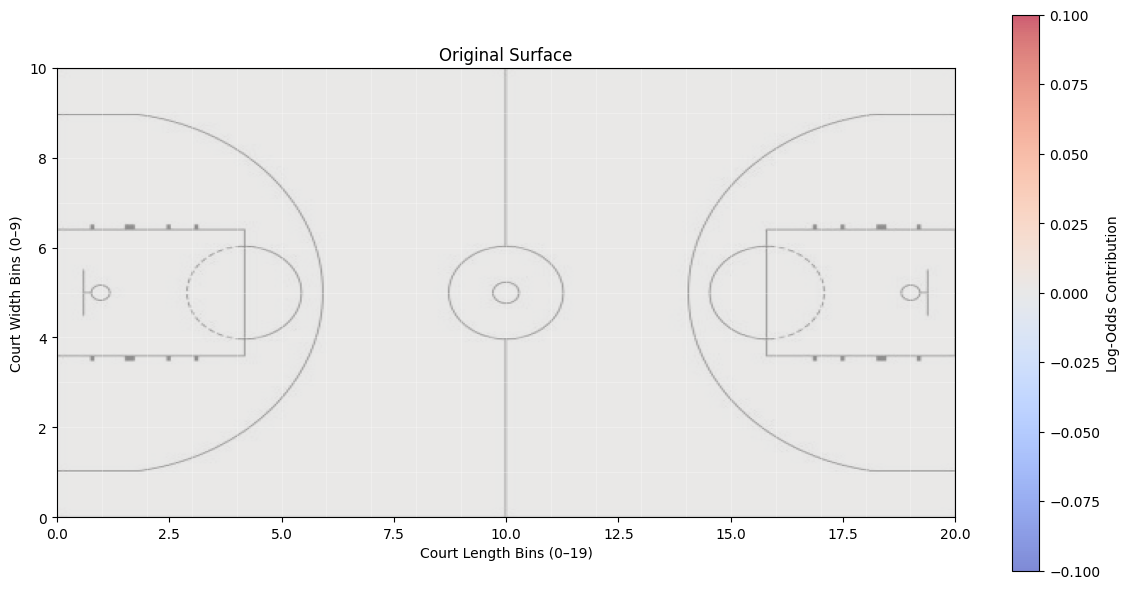

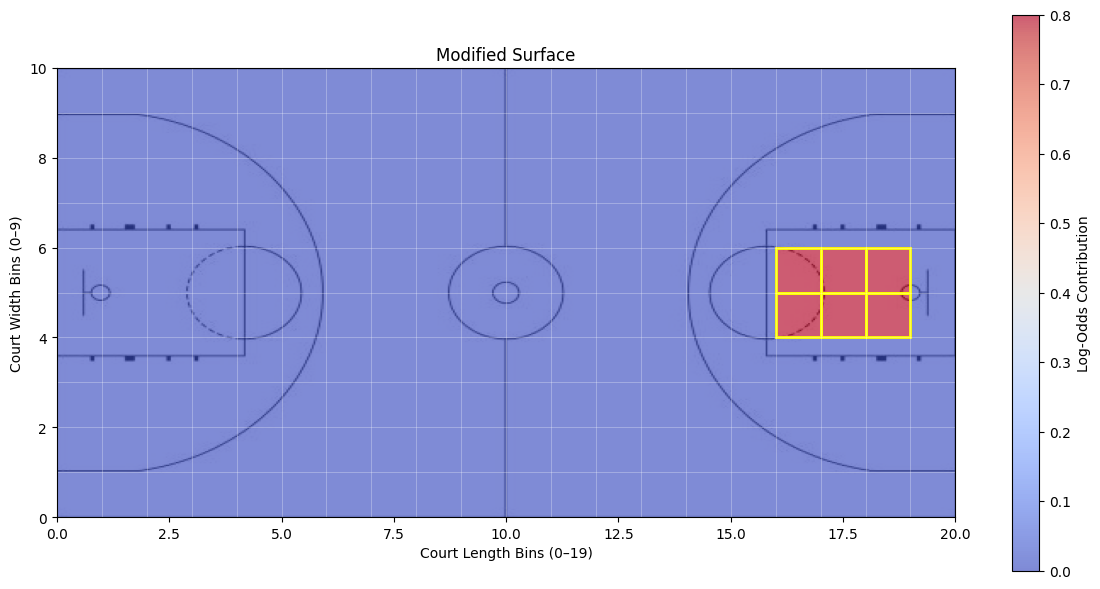

In [2]:
# -------------------------------------------------
# COURT SETTINGS
# -------------------------------------------------

x_bins = 20
y_bins = 10

court_img = Image.open("court.jpg")

# -------------------------------------------------
# 1. CREATE BLANK LOG-ODDS MATRIX
# -------------------------------------------------

# Each cell represents a sector's contribution to scoring log-odds
propensity_matrix = np.zeros((x_bins, y_bins))

# -------------------------------------------------
# 2. FUNCTION TO MODIFY SECTORS
# -------------------------------------------------

def build_range_updates(length_range, width_range, value):
    x_start, x_end = length_range
    y_start, y_end = width_range

    return {
        (x, y): value
        for x in range(x_start, x_end + 1)
        for y in range(y_start, y_end + 1)
    }


def adjust_sector_propensity(matrix, updates, mode="add"):
    
    new_matrix = matrix.copy()

    for (x, y), value in updates.items():

        if mode == "add":
            new_matrix[x, y] += value

        elif mode == "set":
            new_matrix[x, y] = value

        else:
            raise ValueError("mode must be 'add' or 'set'")

    return new_matrix


# -------------------------------------------------
# 3. PLOT FUNCTION
# -------------------------------------------------

def plot_surface(matrix, title="Sector Log-Odds Surface", changed=None):

    fig, ax = plt.subplots(figsize=(12,6))

    ax.imshow(court_img, extent=[0,x_bins,0,y_bins], aspect="auto")

    img = ax.imshow(
        matrix.T,
        origin="lower",
        cmap="coolwarm",
        extent=[0,x_bins,0,y_bins],
        alpha=0.65
    )

    # grid lines
    for x in range(x_bins+1):
        ax.axvline(x,color="white",lw=0.5,alpha=0.4)

    for y in range(y_bins+1):
        ax.axhline(y,color="white",lw=0.5,alpha=0.4)

    # highlight changed sectors
    if changed is not None:
        for (x,y) in changed:
            rect = Rectangle((x,y),1,1,
                             fill=False,
                             edgecolor="yellow",
                             lw=2)
            ax.add_patch(rect)

    plt.colorbar(img, ax=ax, label="Log-Odds Contribution")

    ax.set_xlim(0,x_bins)
    ax.set_ylim(0,y_bins)

    ax.set_title(title)
    ax.set_xlabel("Court Length Bins (0–19)")
    ax.set_ylabel("Court Width Bins (0–9)")

    plt.tight_layout()
    plt.show()


# -------------------------------------------------
# 4. EXAMPLE: BATCH MODIFY A RANGE OF SECTORS
# -------------------------------------------------

length_range = (16, 18)
width_range = (4, 5)
value = 0.8

updates = build_range_updates(length_range, width_range, value)

modified_matrix = adjust_sector_propensity(
    propensity_matrix,
    updates,
    mode="set"
)

# -------------------------------------------------
# 5. PLOT ORIGINAL AND MODIFIED
# -------------------------------------------------

plot_surface(propensity_matrix, "Original Surface")

plot_surface(modified_matrix,
             "Modified Surface",
             changed=updates.keys())

# Example for multiple batch updates:
# updates = {}
# updates.update(build_range_updates((16, 18), (4, 5), 0.8))
# updates.update(build_range_updates((18, 19), (2, 3), -0.4))

In [ ]:
# Adjust the matrix for time, and move hot/cold sectors around
# Create fake games, ~100 samples per game
# Simulate where they scored or not, adjust danger zones to reflect the actual scoring rate
# Play with matrix to reflect actual scoring
# Sectors increase likelihood of scoring
# Check out Codex